# Random action agent

Current storage capacity:
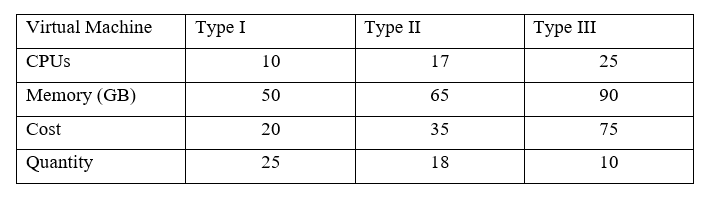

In [1]:
import pprint
import random
import warnings
import numpy as np

from gym import Env
from gym.spaces import Discrete, Box
from distribuited_app import *
from stable_baselines3.common.env_checker import check_env

import gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecCheckNan
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env


warnings.filterwarnings("ignore")

In [2]:
# Replicate runs
TEST_EPISODES = 10

# SIM PARAMETERS
SLA = 0.5
VM_TYPE1 = 10
VM_TYPE2 = 8
VM_TYPE3 = 5
ALPHA = 0.5
BETA = 0.5
GAMMA = 0.97

env = DistributedApp(sla = SLA,
                      vm_1 = VM_TYPE1,
                      vm_2 = VM_TYPE2,
                      vm_3 = VM_TYPE3,
                      alpha = ALPHA,
                      beta = BETA,
                      gamma = GAMMA)

Check if my custom enivorment correctly follow OpenAI Gym structure

In [4]:
check_env(env, warn=0, skip_render_check=1)

In [6]:
def run_episode(print_info=False):
    state = env.reset()
    done = False
    score = 0 
    count = 1
    while not done:
        action = env.action_space.sample()
        
        n_state, reward, done, info = env.step(action)
        if print_info:
            pp = pprint.PrettyPrinter(indent=5)
            print("--------------------------------------- STEP : ", count)
            print("Action: ", action)
            print("Reward: ", reward)
            print("Next state: ", n_state)
            pp.pprint(info)
            print("-----------------------------------------")
        
        score+=reward
        count+=1  
    return score

Run single episode and look up detailed information step by step

In [7]:
run_episode(print_info=True)

--------------------------------------- STEP :  1
Action:  0
Reward:  0.27
Next state:  [271.36484]
{    'Current cost': 271.67,
     'No of VMs': 21,
     'Quality of Service ': 9.0,
     'TCP': 193.0,
     'VM type I': 8,
     'VM type II': 8,
     'VM type III': 5}
-----------------------------------------
--------------------------------------- STEP :  2
Action:  6
Reward:  0.27
Next state:  [259.01743]
{    'Current cost': 246.67,
     'No of VMs': 20,
     'Quality of Service ': 4.0,
     'TCP': 176.0,
     'VM type I': 8,
     'VM type II': 8,
     'VM type III': 4}
-----------------------------------------
--------------------------------------- STEP :  3
Action:  0
Reward:  0.26
Next state:  [252.8437]
{    'Current cost': 246.67,
     'No of VMs': 20,
     'Quality of Service ': 2.6667,
     'TCP': 176.0,
     'VM type I': 8,
     'VM type II': 8,
     'VM type III': 4}
-----------------------------------------
--------------------------------------- STEP :  4
Action:  2
Rewa

24.870000000000008

Run 10 episodes (with no detailed information)

In [9]:
for episode in range(1, TEST_EPISODES+1):
    score = run_episode()
    print('Episode:{} Score:{}'.format(episode, score))

Episode:1 Score:26.429999999999993
Episode:2 Score:21.57999999999999
Episode:3 Score:20.66
Episode:4 Score:23.200000000000003
Episode:5 Score:23.93
Episode:6 Score:23.94
Episode:7 Score:18.49999999999999
Episode:8 Score:21.67
Episode:9 Score:20.37
Episode:10 Score:30.84999999999999


In [10]:
model = A2C("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=25000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 60        |
|    ep_rew_mean        | 20.8      |
| time/                 |           |
|    fps                | 491       |
|    iterations         | 100       |
|    time_elapsed       | 1         |
|    total_timesteps    | 500       |
| train/                |           |
|    entropy_loss       | -1.86     |
|    explained_variance | -0.000346 |
|    learning_rate      | 0.0007    |
|    n_updates          | 99        |
|    policy_loss        | 0.759     |
|    value_loss         | 0.22      |
-------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 60       |
|    ep_rew_mean        | 20.2     |
| time/                 |          |
|    fps                | 504      |
|    iterations         | 200      |
|

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 60       |
|    ep_rew_mean        | 25.4     |
| time/                 |          |
|    fps                | 479      |
|    iterations         | 1400     |
|    time_elapsed       | 14       |
|    total_timesteps    | 7000     |
| train/                |          |
|    entropy_loss       | -1.87    |
|    explained_variance | 0        |
|    learning_rate      | 0.0007   |
|    n_updates          | 1399     |
|    policy_loss        | 0.839    |
|    value_loss         | 0.206    |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 60       |
|    ep_rew_mean        | 26.6     |
| time/                 |          |
|    fps                | 478      |
|    iterations         | 1500     |
|    time_elapsed       | 15       |
|    total_timesteps    | 7500     |
| train/                |          |
|

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 60       |
|    ep_rew_mean        | 34.3     |
| time/                 |          |
|    fps                | 488      |
|    iterations         | 2700     |
|    time_elapsed       | 27       |
|    total_timesteps    | 13500    |
| train/                |          |
|    entropy_loss       | -0.15    |
|    explained_variance | 0        |
|    learning_rate      | 0.0007   |
|    n_updates          | 2699     |
|    policy_loss        | 0.00503  |
|    value_loss         | 0.0433   |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 60       |
|    ep_rew_mean        | 35       |
| time/                 |          |
|    fps                | 487      |
|    iterations         | 2800     |
|    time_elapsed       | 28       |
|    total_timesteps    | 14000    |
| train/                |          |
|

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 60       |
|    ep_rew_mean        | 39.9     |
| time/                 |          |
|    fps                | 379      |
|    iterations         | 4000     |
|    time_elapsed       | 52       |
|    total_timesteps    | 20000    |
| train/                |          |
|    entropy_loss       | -0.218   |
|    explained_variance | 1.19e-07 |
|    learning_rate      | 0.0007   |
|    n_updates          | 3999     |
|    policy_loss        | -0.025   |
|    value_loss         | 0.00148  |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 60       |
|    ep_rew_mean        | 39.8     |
| time/                 |          |
|    fps                | 380      |
|    iterations         | 4100     |
|    time_elapsed       | 53       |
|    total_timesteps    | 20500    |
| train/                |          |
|